# Imports

In [1]:
import os

# Check if the dataset directory exists
dataset_path = '/kaggle/input/seadronessee-yolo-2029/seaDronesSee_yolo'
if os.path.exists(dataset_path):
    print("Dataset found!")
else:
    print("Dataset not found, check the path.")

Dataset found!


In [2]:
!git clone https://github.com/mebn/ultralytics.git
!cd ultralytics && git pull && cd ..
!pip install -e ultralytics

Cloning into 'ultralytics'...
remote: Enumerating objects: 36417, done.
remote: Counting objects: 100% (286/286), done.
remote: Compressing objects: 100% (247/247), done.
remote: Total 36417 (delta 142), reused 40 (delta 39), pack-reused 36131 (from 3)
Receiving objects: 100% (36417/36417), 22.26 MiB | 28.71 MiB/s, done.
Resolving deltas: 100% (26241/26241), done.
Already up to date.
Obtaining file:///kaggle/working/ultralytics
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for ultralytics (pyproject.toml) ... done
  Created wheel for ultralytics: filename=ultralytics-8.3.103-0.editable-py3-none-any.whl size=23153 sha256=e168b873c9e1555a73b072d920a6f6ca1f3a3de33f020913df49280551d7a050
  Stored in directory: /tmp/pip-ephem-wheel-cache-o983pcxe/wheels/1b/eb/7d/853f2df0532389050170c8cd117b40e1fef8d125854a910fe6

In [3]:
import os
import torch
import torchvision
import torch.nn as nn
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torchvision.models.feature_extraction import create_feature_extractor
import cv2
import matplotlib.pyplot as plt

import sys
sys.path.append("/kaggle/working/ultralytics")
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# Replacing backbone and initialization

In [4]:
model_file = "/kaggle/working/yolo11-efficientnet_cbam.yaml"


with open(model_file, "w") as f:
    f.write("""
nc: 80
scales:
  n: [1, 1, 1024]

backbone:
  - [-1, 1, TorchVision, [1280, efficientnet_b0, DEFAULT, True, 2, True]]  # 0

head:
  # === Attention after backbone ===
  - [0, 1, Index, [40, 4]]           # 1: P3
  - [1, 1, CBAM, [40, 7]]            # 2

  - [0, 1, Index, [112, 6]]          # 3: P4
  - [3, 1, CBAM, [112]]              # 4

  - [0, 1, Index, [320, 8]]          # 5: P5
  - [5, 1, CBAM, [320]]              # 6

  # === Projection (nano-scaled channels) ===
  - [2, 1, Conv, [64, 1, 1]]         # 7: P3 → 64
  - [4, 1, Conv, [128, 1, 1]]        # 8: P4 → 128
  - [6, 1, Conv, [256, 1, 1]]        # 9: P5 → 256

  # === FPN: P5 → P4 ===
  - [9, 1, nn.Upsample, [None, 2, "nearest"]]   # 10
  - [[10, 8], 1, Concat, [1]]                   # 11
  - [-1, 2, C3k2, [128, False]]                 # 12
  - [12, 1, CBAM, [128]]                        # 13

  # === FPN: P4 → P3 ===
  - [13, 1, nn.Upsample, [None, 2, "nearest"]]  # 14
  - [[14, 7], 1, Concat, [1]]                   # 15
  - [-1, 2, C3k2, [64, False]]                  # 16
  - [16, 1, CBAM, [64]]                         # 17

  # === PAN bottom-up ===
  - [17, 1, Conv, [64, 3, 2]]                   # 18
  - [[18, 13], 1, Concat, [1]]                  # 19
  - [-1, 2, C3k2, [128, False]]                 # 20
  - [20, 1, CBAM, [128]]                        # 21

  - [21, 1, Conv, [128, 3, 2]]                  # 22
  - [[22, 9], 1, Concat, [1]]                   # 23
  - [-1, 2, C3k2, [256, True]]                  # 24
  - [24, 1, CBAM, [256]]                        # 25

  # === Detection ===
  - [[17, 21, 25], 1, Detect, [nc]]             # 26

  

  
# backbone layers:
# 0 torch.Size([1, 3, 640, 640])
# 1 torch.Size([1, 32, 320, 320])
# 2 torch.Size([1, 16, 320, 320])
# 3 torch.Size([1, 24, 160, 160])
# 4 torch.Size([1, 40, 80, 80])
# 5 torch.Size([1, 80, 40, 40])
# 6 torch.Size([1, 112, 40, 40])
# 7 torch.Size([1, 192, 20, 20])
# 8 torch.Size([1, 320, 20, 20])
# 9 torch.Size([1, 1280, 20, 20])
""")


model = YOLO(model_file, task="detect")

WARNING ⚠️ no model scale passed. Assuming scale='n'.


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 198MB/s]


# Data

In [6]:
data_file = "/kaggle/working/data.yaml"

with open(data_file, "w") as f:
    f.write("""train: /kaggle/input/seadronessee-yolo-2029/seaDronesSee_yolo/images/train
val: /kaggle/input/seadronessee-yolo-2029/seaDronesSee_yolo/images/val
test: /kaggle/input/seadronessee-yolo-2029/seaDronesSee_yolo/images/test
nc: 1
names: ["human"]""")

# Fine-tuning

In [7]:
model.train(
    data=data_file,
    epochs=200,
    patience=10,
    imgsz=640,
    batch=16,
    name="yolo11_efficientnet_cbam_epoch"
)

!zip -r yolo11_efficientnet_cbam.zip /kaggle/working

Ultralytics 8.3.103 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: task=detect, mode=train, model=/kaggle/working/yolo11-efficientnet_cbam.yaml, data=/kaggle/working/data.yaml, epochs=200, time=None, patience=10, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=yolo11_efficientnet_cbam_epoch, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_c

100%|██████████| 755k/755k [00:00<00:00, 42.5MB/s]


Overriding model.yaml nc=80 with nc=1
WARNING ⚠️ no model scale passed. Assuming scale='n'.

                   from  n    params  module                                       arguments                     
  0                  -1  1   4007548  ultralytics.nn.modules.block.TorchVision     ['efficientnet_b0', 'DEFAULT', True, 2, True]
  1                   0  1         0  ultralytics.nn.modules.conv.Index            [4]                           
  2                   1  1      1738  ultralytics.nn.modules.conv.CBAM             [40, 7]                       
  3                   0  1         0  ultralytics.nn.modules.conv.Index            [6]                           
  4                   3  1     12754  ultralytics.nn.modules.conv.CBAM             [112]                         
  5                   0  1         0  ultralytics.nn.modules.conv.Index            [8]                           
  6                   5  1    102818  ultralytics.nn.modules.conv.CBAM             [320]      

100%|██████████| 5.35M/5.35M [00:00<00:00, 178MB/s]


AMP: checks passed ✅


...


99 epochs completed in 1.912 hours.
Optimizer stripped from /kaggle/working/ultralytics/runs/detect/yolo11_efficientnet_cbam_epoch/weights/last.pt, 12.2MB
Optimizer stripped from /kaggle/working/ultralytics/runs/detect/yolo11_efficientnet_cbam_epoch/weights/best.pt, 12.2MB

Validating /kaggle/working/ultralytics/runs/detect/yolo11_efficientnet_cbam_epoch/weights/best.pt...
Ultralytics 8.3.103 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
YOLO11-efficientnet_cbam summary: 336 layers, 5,859,573 parameters, 0 gradients, 11.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:04<00:00,  1.86it/s]


                   all        253       1267      0.765       0.59      0.646      0.279


/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


Speed: 0.2ms preprocess, 5.4ms inference, 0.0ms loss, 2.9ms postprocess per image
Results saved to /kaggle/working/ultralytics/runs/detect/yolo11_efficientnet_cbam_epoch
  adding: kaggle/working/ (stored 0%)
  adding: kaggle/working/.virtual_documents/ (stored 0%)
  adding: kaggle/working/data.yaml (deflated 56%)
  adding: kaggle/working/yolo11n.pt (deflated 11%)
  adding: kaggle/working/ultralytics/ (stored 0%)
  adding: kaggle/working/ultralytics/CONTRIBUTING.md (deflated 65%)
  adding: kaggle/working/ultralytics/LICENSE (deflated 66%)
  adding: kaggle/working/ultralytics/mkdocs.yml (deflated 75%)
  adding: kaggle/working/ultralytics/docker/ (stored 0%)
  adding: kaggle/working/ultralytics/docker/Dockerfile (deflated 57%)
  adding: kaggle/working/ultralytics/docker/Dockerfile-jetson-jetpack4 (deflated 61%)
  adding: kaggle/working/ultralytics/docker/Dockerfile-runner (deflated 55%)
  adding: kaggle/working/ultralytics/docker/Dockerfile-jetson-jetpack6 (deflated 61%)
  adding: kaggle/

In [8]:
!zip -r yolo11_efficientnet_cbam_runs.zip /kaggle/working/ultralytics/runs

  adding: kaggle/working/ultralytics/runs/ (stored 0%)
  adding: kaggle/working/ultralytics/runs/detect/ (stored 0%)
  adding: kaggle/working/ultralytics/runs/detect/yolo11_efficientnet_cbam_epoch/ (stored 0%)
  adding: kaggle/working/ultralytics/runs/detect/yolo11_efficientnet_cbam_epoch/results.png (deflated 9%)
  adding: kaggle/working/ultralytics/runs/detect/yolo11_efficientnet_cbam_epoch/labels_correlogram.jpg (deflated 43%)
  adding: kaggle/working/ultralytics/runs/detect/yolo11_efficientnet_cbam_epoch/confusion_matrix_normalized.png (deflated 38%)
  adding: kaggle/working/ultralytics/runs/detect/yolo11_efficientnet_cbam_epoch/results.csv (deflated 61%)
  adding: kaggle/working/ultralytics/runs/detect/yolo11_efficientnet_cbam_epoch/val_batch0_labels.jpg (deflated 8%)
  adding: kaggle/working/ultralytics/runs/detect/yolo11_efficientnet_cbam_epoch/labels.jpg (deflated 33%)
  adding: kaggle/working/ultralytics/runs/detect/yolo11_efficientnet_cbam_epoch/val_batch2_labels.jpg (deflate

# Testing

In [9]:
def show_img_with_boxes(res):
    img = res[0].plot()
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()


image 1/1 /kaggle/input/seadronessee-yolo-2029/seaDronesSee_yolo/images/test/10209.jpg: 384x640 7 humans, 18.1ms
Speed: 2.3ms preprocess, 18.1ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)


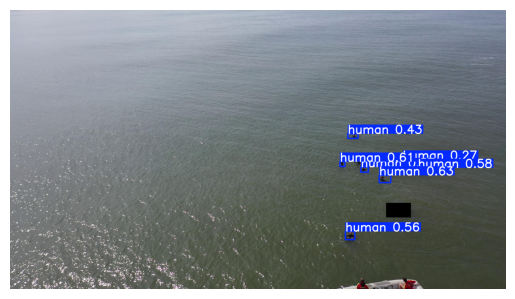

Ultralytics 8.3.103 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
YOLO11-efficientnet_cbam summary: 336 layers, 5,859,573 parameters, 0 gradients, 11.4 GFLOPs


val: Scanning /kaggle/input/seadronessee-yolo-2029/seaDronesSee_yolo/labels/test... 253 images, 0 backgrounds, 0 corrupt: 100%|██████████| 253/253 [00:00<00:00, 854.46it/s]


val: WARNING ⚠️ Cache directory /kaggle/input/seadronessee-yolo-2029/seaDronesSee_yolo/labels is not writeable, cache not saved.


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 16/16 [00:06<00:00,  2.56it/s]


                   all        253       1363      0.794      0.652      0.685      0.297


/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


Speed: 1.1ms preprocess, 4.4ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to /kaggle/working/ultralytics/runs/detect/val4
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a069f2731c0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.0

In [14]:
model = YOLO("/kaggle/working/ultralytics/runs/detect/yolo11_efficientnet_cbam_epoch/weights/best.pt")

img = "/kaggle/input/seadronessee-yolo-2029/seaDronesSee_yolo/images/test/10209.jpg"

results = model(img)
show_img_with_boxes(results)

metrics = model.val(
    data=data_file,
    split="test"
)

print(metrics)